# Condensed Matter: TFIM Phase Classification

Classify finite-size transverse-field Ising model samples as ferromagnetic or paramagnetic from exact-diagonalization correlation features. The quantum model uses the package embedding utilities with a precomputed quantum kernel and is checked against a classical logistic baseline.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** The transverse-field Ising model (TFIM) describes interacting spin-1/2 degrees of freedom with a competition between nearest-neighbor alignment and a transverse field. The notebook uses exact diagonalization on a small spin chain to classify whether a sample lies on the ferromagnetic side or paramagnetic side of the transition.

**Explicit variables.** `n_spins` is the number of spins. `g` is the transverse-field strength. `X_i` and `Z_i` are Pauli operators on spin `i`. `H = -sum_i Z_i Z_{i+1} - g sum_i X_i` is the Hamiltonian. `zz_corr` is the mean nearest-neighbor `Z_i Z_{i+1}` ground-state correlation. `x_mag` is the mean transverse `X_i` ground-state magnetization. `x_raw = [zz_corr, x_mag]` is the classical feature vector. `y = 0` denotes the low-field ferromagnetic side and `y = 1` denotes the high-field paramagnetic side. `k_train` and `k_test` are precomputed quantum-kernel matrices.

**Quantum advantage context.** A quantum kernel can represent similarity through Hilbert-space overlaps that may be difficult for simple classical feature maps to mimic on larger or more structured quantum data. This small notebook does **not** demonstrate quantum advantage; it validates that the package can build and evaluate a quantum-kernel workflow on a physically meaningful phase-classification problem with a classical sanity baseline.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import pennylane as pl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from qml.embeddings import apply_angle_embedding
from qml.metrics import accuracy_score

import matplotlib.pyplot as plt
from qml.reporting import print_section


## Domain simulator

The dataset comes from the one-dimensional transverse-field Ising Hamiltonian `H = -sum Z_i Z_{i+1} - g sum X_i` on four spins. Each sample uses two physics features: nearest-neighbor `ZZ` correlation and transverse `X` magnetization.

In [2]:
def kron_all(ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out


def local_operator(single_site_op, site, n_spins):
    identity = np.eye(2)
    return kron_all([single_site_op if i == site else identity for i in range(n_spins)])


def two_site_operator(op_a, site_a, op_b, site_b, n_spins):
    identity = np.eye(2)
    ops = []
    for i in range(n_spins):
        if i == site_a:
            ops.append(op_a)
        elif i == site_b:
            ops.append(op_b)
        else:
            ops.append(identity)
    return kron_all(ops)


def tfim_features(g_values, n_spins=4):
    sx = np.array([[0.0, 1.0], [1.0, 0.0]])
    sz = np.array([[1.0, 0.0], [0.0, -1.0]])
    dim = 2**n_spins
    features = []

    zz_terms = [two_site_operator(sz, i, sz, (i + 1) % n_spins, n_spins) for i in range(n_spins)]
    x_terms = [local_operator(sx, i, n_spins) for i in range(n_spins)]

    for g in g_values:
        hamiltonian = np.zeros((dim, dim))
        for term in zz_terms:
            hamiltonian -= term
        for term in x_terms:
            hamiltonian -= g * term

        eigvals, eigvecs = np.linalg.eigh(hamiltonian)
        ground_state = eigvecs[:, np.argmin(eigvals)]
        zz_corr = np.mean(
            [np.real(np.vdot(ground_state, term @ ground_state)) for term in zz_terms]
        )
        x_mag = np.mean([np.real(np.vdot(ground_state, term @ ground_state)) for term in x_terms])
        features.append([zz_corr, x_mag])

    return np.asarray(features, dtype=float)


g_values = np.linspace(0.25, 1.75, 48)
x_raw = tfim_features(g_values)
y = (g_values >= 1.0).astype(int)

print_section(
    "Dataset",
    [
        ("Samples", int(len(y))),
        ("feature_shape", list(x_raw.shape)),
        ("Labels", np.bincount(y).tolist()),
    ],
)

Dataset
+---------------+----------+
| Metric        | Value    |
+---------------+----------+
| Samples       | 48       |
| feature_shape | [48, 2]  |
| Labels        | [24, 24] |
+---------------+----------+



## Quantum-kernel package client

The notebook uses the package's angle embedding inside a PennyLane fidelity kernel, then trains a precomputed-kernel SVM. The rest of the evaluation uses package metrics.

In [3]:
x_train, x_test, y_train, y_test, g_train, g_test = train_test_split(
    x_raw, y, g_values, test_size=0.3, random_state=7, stratify=y
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

n_qubits = x_train.shape[1]
wires = list(range(n_qubits))
dev = pl.device("default.qubit", wires=n_qubits, seed=7)


def feature_map(x):
    apply_angle_embedding(x, wires=wires)
    if n_qubits > 1:
        for left, right in zip(wires[:-1], wires[1:]):
            pl.CNOT(wires=[left, right])


@pl.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map(x1)
    pl.adjoint(feature_map)(x2)
    return pl.probs(wires=wires)


def quantum_kernel(x1, x2):
    return float(kernel_circuit(x1, x2)[0])


def kernel_matrix(a, b):
    return np.asarray([[quantum_kernel(xi, xj) for xj in b] for xi in a], dtype=float)


k_train = kernel_matrix(x_train, x_train)
k_test = kernel_matrix(x_test, x_train)

quantum_clf = SVC(kernel="precomputed")
quantum_clf.fit(k_train, y_train)
y_pred = quantum_clf.predict(k_test)

classical_clf = LogisticRegression(random_state=7, max_iter=1000)
classical_clf.fit(x_train, y_train)
y_classical = classical_clf.predict(x_test)

results = {
    "quantum_kernel_accuracy": accuracy_score(y_test, y_pred),
    "logistic_accuracy": accuracy_score(y_test, y_classical),
    "kernel_train_shape": list(k_train.shape),
    "kernel_diag_min": float(np.min(np.diag(k_train))),
    "kernel_symmetry_error": float(np.max(np.abs(k_train - k_train.T))),
}
print_section(
    "Results",
    [
        ("Quantum kernel accuracy", results["quantum_kernel_accuracy"]),
        ("Logistic accuracy", results["logistic_accuracy"]),
        ("Kernel train shape", results["kernel_train_shape"]),
        ("Kernel diagonal minimum", results["kernel_diag_min"]),
        ("Kernel symmetry error", results["kernel_symmetry_error"]),
    ],
)

Results
+-------------------------+-------------+
| Metric                  | Value       |
+-------------------------+-------------+
| Quantum kernel accuracy | 1           |
| Logistic accuracy       | 1           |
| Kernel train shape      | [33, 33]    |
| Kernel diagonal minimum | 1           |
| Kernel symmetry error   | 4.44089e-16 |
+-------------------------+-------------+



## Plots

The plots show the simulated physics features, the quantum-kernel matrix, and the held-out phase predictions ordered by transverse field.

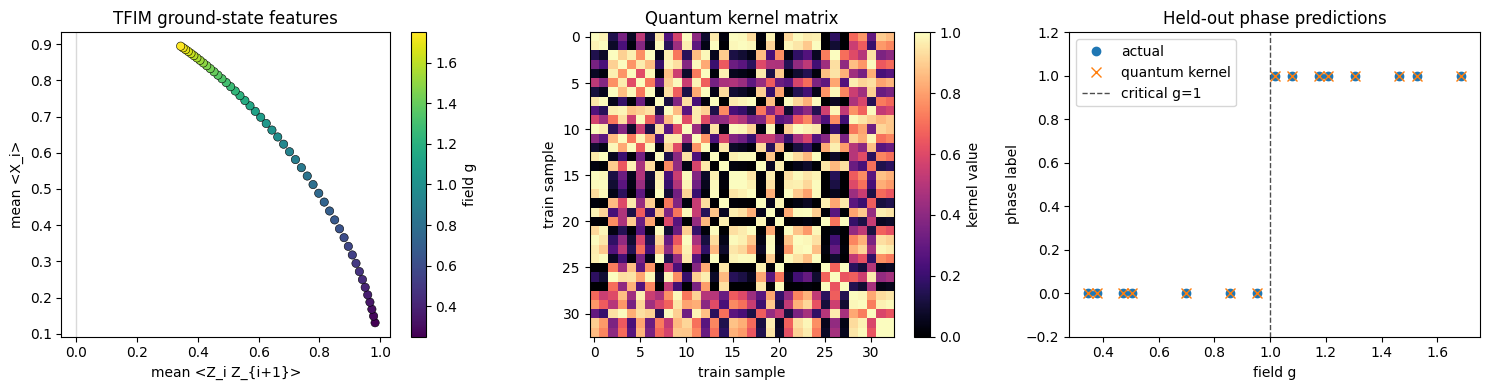

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter = axes[0].scatter(
    x_raw[:, 0],
    x_raw[:, 1],
    c=g_values,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.4,
)
axes[0].axvline(0.0, color="0.85", linewidth=1)
axes[0].set_title("TFIM ground-state features")
axes[0].set_xlabel("mean <Z_i Z_{i+1}>")
axes[0].set_ylabel("mean <X_i>")
fig.colorbar(scatter, ax=axes[0], label="field g")

im = axes[1].imshow(k_train, cmap="magma", vmin=0.0, vmax=1.0)
axes[1].set_title("Quantum kernel matrix")
axes[1].set_xlabel("train sample")
axes[1].set_ylabel("train sample")
fig.colorbar(im, ax=axes[1], label="kernel value")

order = np.argsort(g_test)
axes[2].plot(g_test[order], y_test[order], "o", label="actual", markersize=6)
axes[2].plot(g_test[order], y_pred[order], "x", label="quantum kernel", markersize=7)
axes[2].axvline(1.0, color="0.3", linestyle="--", linewidth=1, label="critical g=1")
axes[2].set_ylim(-0.2, 1.2)
axes[2].set_title("Held-out phase predictions")
axes[2].set_xlabel("field g")
axes[2].set_ylabel("phase label")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This cell is intentionally last. It prints enough information to confirm that the notebook generated a real TFIM dataset, built a valid quantum kernel, and achieved non-trivial phase classification accuracy.

In [5]:
validation = {
    "dataset": {
        "problem": "finite_size_tfim_phase_classification",
        "n_spins": 4,
        "n_samples": int(len(y)),
        "feature_names": ["nearest_neighbor_zz_correlation", "transverse_x_magnetization"],
        "test_fields": np.round(g_test, 3).tolist(),
        "test_labels": y_test.astype(int).tolist(),
        "test_predictions": y_pred.astype(int).tolist(),
    },
    "results": results,
    "passed": bool(
        results["quantum_kernel_accuracy"] >= 0.75
        and results["kernel_diag_min"] > 0.99
        and results["kernel_symmetry_error"] < 1e-10
        and len(set(y_pred.tolist())) == 2
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("N spins", validation["dataset"]["n_spins"]),
        ("Samples", validation["dataset"]["n_samples"]),
        ("Feature names", validation["dataset"]["feature_names"]),
        ("Test fields", validation["dataset"]["test_fields"]),
        ("Test labels", validation["dataset"]["test_labels"]),
        ("Test predictions", validation["dataset"]["test_predictions"]),
    ],
)
print_section(
    "Results",
    [
        ("Quantum kernel accuracy", validation["results"]["quantum_kernel_accuracy"]),
        ("Logistic accuracy", validation["results"]["logistic_accuracy"]),
        ("Kernel train shape", validation["results"]["kernel_train_shape"]),
        ("Kernel diagonal minimum", validation["results"]["kernel_diag_min"]),
        ("Kernel symmetry error", validation["results"]["kernel_symmetry_error"]),
    ],
)
print("Interpretation")
print("The TFIM feature set is cleanly separable in this finite-size example.")
print(
    "Both the quantum kernel model and the logistic baseline solve the held-out split perfectly, so this validates the workflow rather than demonstrating quantum advantage."
)
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+------------------+----------------------------------------------------------------------------------------------------------+
| Metric           | Value                                                                                                    |
+------------------+----------------------------------------------------------------------------------------------------------+
| Problem          | finite_size_tfim_phase_classification                                                                    |
| N spins          | 4                                                                                                        |
| Samples          | 48                                                                                                       |
| Feature names    | [nearest_neighbor_zz_correlation, transverse_x_magnetization]                                            |
| Test fields      | [0.473, 1.463, 1.686, 0.697, 0.952, 0.346, 1.207, 0.378, 1.176, 